# 🚀 Lab 31: Descriptive Statistics with Pandas

### 📖 Purpose
In this lab, you will learn how to use **pandas** to explore data and calculate descriptive statistics. Descriptive statistics help us summarize data so we can understand what is typical, what is unusual, and how values are distributed.

You will work with two realistic sample datasets:
* A **Fintech dataset** containing customer financial information.
* A **Healthcare dataset** containing patient health measurements.

### 🎯 Objectives
By the end of this lab, you will be able to:
* Load and explore datasets using pandas.
* Calculate fundamental descriptive statistics (mean, median, mode, std, min, max).
* Use the `.quantile()` method and calculate Interquartile Range (IQR).
* Create histograms to visualize data distributions.
* Interpret statistical results in real-world contexts.
* Perform basic data quality assessments (missing values and outliers).

## 🧰 Prerequisites
* Basic Python understanding (variables, data types).
* Familiarity with lists and dictionaries.
* No prior pandas experience is required!

## ⚙️ Environment Setup
### 💡 ELI10 Explanation
Before we start, we need our toolbox ready. In data analysis, libraries are like toolkits:
* **pandas**: Helps us work with tables (DataFrames).
* **NumPy**: Helps us generate and work with numbers.
* **Matplotlib**: Helps us create charts and graphs.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

# Ignore warnings to keep notebook output clean
warnings.filterwarnings("ignore")

# Optional display settings for cleaner table output
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Set a random seed so results are reproducible
np.random.seed(42)

print("✅ Libraries imported successfully and environment configured.")

✅ Libraries imported successfully and environment configured.


## 📥 Task 1: Environment Setup and Data Loading
### 💡 ELI10 Explanation
A dataset is like a digital spreadsheet. Each row is one person's record, and each column is a specific detail about them (like Age or Balance). We will generate our own data so we don't need to upload any files.

In [2]:
# --- A. Create Fintech Dataset ---
fintech_data = {
    "customer_id": range(1, 101),
    "account_balance": np.random.normal(5000, 2000, 100),
    "monthly_transactions": np.random.poisson(15, 100),
    "credit_score": np.random.normal(650, 100, 100),
    "loan_amount": np.random.exponential(10000, 100),
    "age": np.random.randint(18, 80, 100),
    "annual_income": np.random.normal(50000, 20000, 100)
}

fintech_df = pd.DataFrame(fintech_data)

# Data Cleaning for realism
fintech_df["account_balance"] = np.maximum(fintech_df["account_balance"], 0).round(2)
fintech_df["credit_score"] = np.clip(fintech_df["credit_score"], 300, 850).round(2)
fintech_df["annual_income"] = np.maximum(fintech_df["annual_income"], 20000).round(2)
fintech_df["loan_amount"] = fintech_df["loan_amount"].round(2)

print("💰 Fintech Dataset Created!")
display(fintech_df.head())

# --- B. Create Healthcare Dataset ---
healthcare_data = {
    "patient_id": range(1, 101),
    "age": np.random.randint(1, 90, 100),
    "blood_pressure_systolic": np.random.normal(120, 20, 100),
    "blood_pressure_diastolic": np.random.normal(80, 15, 100),
    "heart_rate": np.random.normal(72, 12, 100),
    "cholesterol": np.random.normal(200, 40, 100),
    "bmi": np.random.normal(25, 5, 100),
    "hospital_stay_days": np.random.poisson(3, 100)
}

healthcare_df = pd.DataFrame(healthcare_data)

# Data Cleaning for realism
healthcare_df["blood_pressure_systolic"] = np.clip(healthcare_df["blood_pressure_systolic"], 80, 200).round(2)
healthcare_df["blood_pressure_diastolic"] = np.clip(healthcare_df["blood_pressure_diastolic"], 50, 120).round(2)
healthcare_df["heart_rate"] = np.clip(healthcare_df["heart_rate"], 40, 150).round(2)
healthcare_df["cholesterol"] = np.maximum(healthcare_df["cholesterol"], 100).round(2)
healthcare_df["bmi"] = np.clip(healthcare_df["bmi"], 15, 50).round(2)

print("\n🏥 Healthcare Dataset Created!")
display(healthcare_df.head())

💰 Fintech Dataset Created!


,customer_id,account_balance,monthly_transactions,credit_score,loan_amount,age,annual_income
0,1,5993.43,14,685.70,26990.18,74,36987.15
1,2,4723.47,10,580.71,20103.92,39,40257.49
2,3,6295.38,23,739.96,462.73,64,38152.12
3,4,8046.06,15,680.73,267.21,73,32720.18
4,5,4531.69,25,731.29,4723.48,47,50970.43



🏥 Healthcare Dataset Created!


,patient_id,age,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,cholesterol,bmi,hospital_stay_days
0,1,36,102.58,83.46,78.18,193.65,33.30,3
1,2,36,87.76,86.48,86.33,152.53,31.38,3
2,3,26,146.99,88.12,73.16,185.19,26.15,6
3,4,43,113.41,81.99,54.00,200.93,15.00,2
4,5,27,111.04,87.80,79.58,174.00,21.48,5


In [3]:
# --- C. Basic Exploration ---
print("--- Fintech Info ---")
fintech_df.info()
print("\n--- Healthcare Info ---")
healthcare_df.info()

--- Fintech Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           100 non-null    int64  
 1   account_balance       100 non-null    float64
 2   monthly_transactions  100 non-null    int64  
 3   credit_score          100 non-null    float64
 4   loan_amount           100 non-null    float64
 5   age                   100 non-null    int64  
 6   annual_income         100 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 5.6 KB

--- Healthcare Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                100 non-null    int64  
 1   age                       100 non-null    int64  
 2   blood_pressure

## 📊 Task 2: Calculate Basic Descriptive Statistics
### 💡 ELI10 Explanation
Statistics give us a "snapshot" of our data:
* **Mean**: The average.
* **Median**: The middle point (halfway mark).
* **Standard Deviation**: How much the numbers "wiggle" or spread out from the average.

In [4]:
def format_value(column, value):
    """Helper to add dollar signs to financial data."""
    if any(k in column for k in ["balance", "income", "loan"]):
        return f"${value:,.2f}"
    return f"{value:.2f}"

# 1. Mean
print("=== MEAN VALUES ===")
print("Fintech:", {col: format_value(col, val) for col, val in fintech_df.select_dtypes(include=[np.number]).mean().items()})

# 2. Median
print("\n=== MEDIAN VALUES ===")
print("Healthcare:", healthcare_df.select_dtypes(include=[np.number]).median().to_dict())

# 3. Standard Deviation
print("\n=== STANDARD DEVIATION ===")
print("Fintech Std Dev:", fintech_df.select_dtypes(include=[np.number]).std().round(2).to_dict())

# 4. Min/Max
print("\n=== MIN/MAX ===")
print(f"Fintech Age Range: {fintech_df['age'].min()} to {fintech_df['age'].max()}")

=== MEAN VALUES ===
Fintech: {'customer_id': '50.50', 'account_balance': '$4,794.70', 'monthly_transactions': '14.96', 'credit_score': '661.09', 'loan_amount': '$10,548.93', 'age': '51.25', 'annual_income': '$48,376.91'}

=== MEDIAN VALUES ===
Healthcare: {'patient_id': 50.5, 'age': 46.0, 'blood_pressure_systolic': 121.25, 'blood_pressure_diastolic': 80.71000000000001, 'heart_rate': 73.115, 'cholesterol': 203.36, 'bmi': 25.03, 'hospital_stay_days': 3.0}

=== STANDARD DEVIATION ===
Fintech Std Dev: {'customer_id': 29.01, 'account_balance': 1809.78, 'monthly_transactions': 4.19, 'credit_score': 84.16, 'loan_amount': 12638.26, 'age': 17.26, 'annual_income': 16846.9}

=== MIN/MAX ===
Fintech Age Range: 18 to 79


## 📐 Task 3: Quantile Analysis and IQR
### 💡 ELI10 Explanation
Quantiles are like slicing a pizza. The **25th percentile (Q1)** is the first quarter mark. The **75th percentile (Q3)** is the three-quarter mark. The space between them is the **IQR**, which represents the "middle 50%" of our data.

In [5]:
def calculate_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    return q1, q3, iqr

print("--- Fintech Quantiles (25%, 50%, 75%) ---")
print(fintech_df[['account_balance', 'credit_score']].quantile([0.25, 0.5, 0.75]))

print("\n--- Healthcare IQR Examples ---")
for col in ["age", "blood_pressure_systolic"]:
    q1, q3, iqr = calculate_iqr(healthcare_df, col)
    print(f"{col.title()}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")

--- Fintech Quantiles (25%, 50%, 75%) ---
      account_balance  credit_score
0.25        3798.1875       593.300
0.50        4746.0850       659.735
0.75        5811.9075       714.270

--- Healthcare IQR Examples ---
Age: Q1=25.75, Q3=63.00, IQR=37.25
Blood_Pressure_Systolic: Q1=108.37, Q3=137.49, IQR=29.12


## 📈 Task 4: Visualizing Distributions with Histograms
### 💡 ELI10 Explanation
A histogram shows us the "shape" of our data. Are most people in the middle? Or are there lots of people at the extremes?

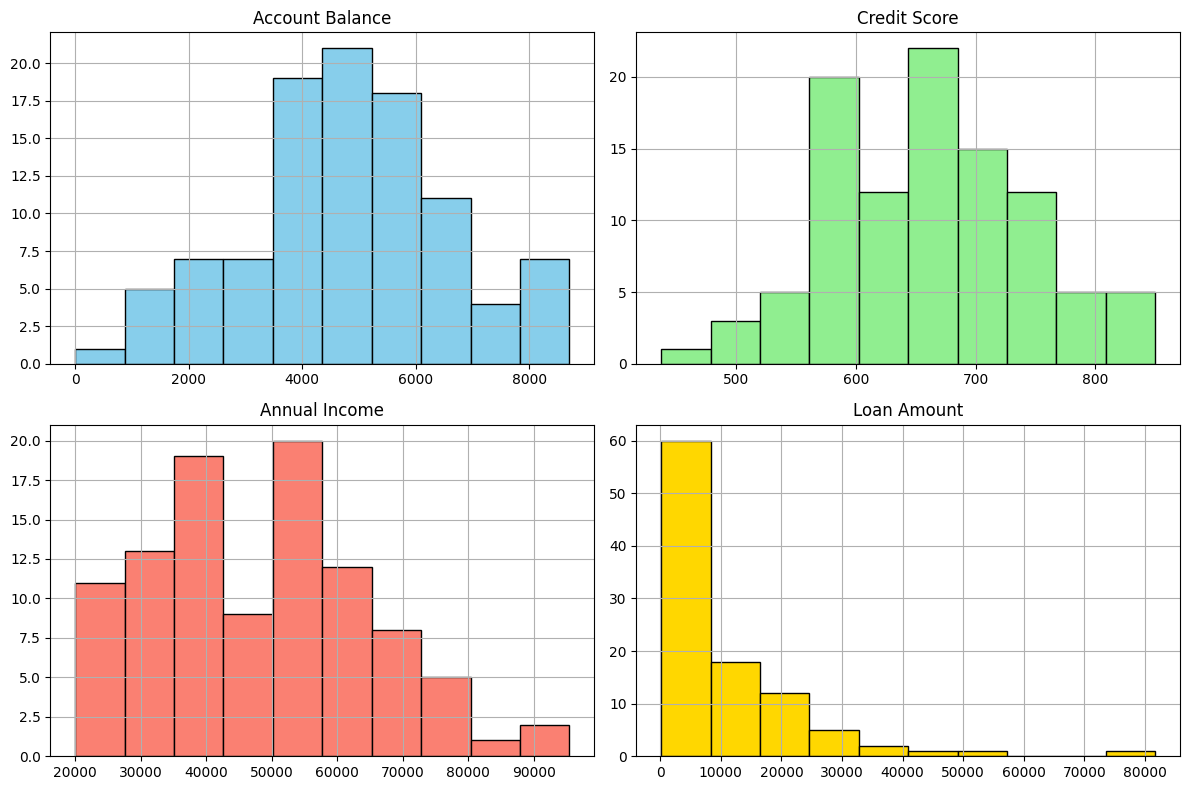

In [6]:
# Subplots for Fintech
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fintech_df["account_balance"].hist(ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title("Account Balance")
fintech_df["credit_score"].hist(ax=axes[0,1], color='lightgreen', edgecolor='black')
axes[0,1].set_title("Credit Score")
fintech_df["annual_income"].hist(ax=axes[1,0], color='salmon', edgecolor='black')
axes[1,0].set_title("Annual Income")
fintech_df["loan_amount"].hist(ax=axes[1,1], color='gold', edgecolor='black')
axes[1,1].set_title("Loan Amount")
plt.tight_layout()
plt.show()

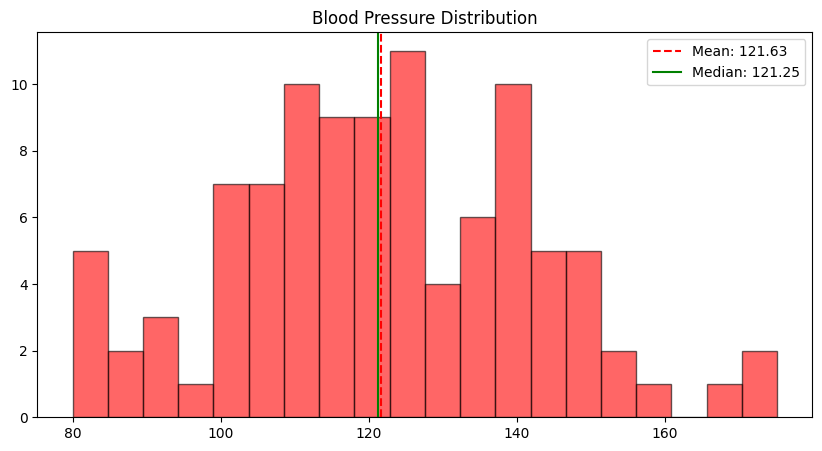

In [7]:
def create_enhanced_histogram(data, column, title, color="blue"):
    plt.figure(figsize=(10, 5))
    plt.hist(data[column], bins=20, color=color, alpha=0.6, edgecolor='black')

    # Add reference lines
    plt.axvline(data[column].mean(), color='red', linestyle='--', label=f'Mean: {data[column].mean():.2f}')
    plt.axvline(data[column].median(), color='green', linestyle='-', label=f'Median: {data[column].median():.2f}')

    plt.title(title)
    plt.legend()
    plt.show()

create_enhanced_histogram(healthcare_df, "blood_pressure_systolic", "Blood Pressure Distribution", "red")

## 🧾 Task 5: Comprehensive Statistical Summary
### 💡 ELI10 Explanation
Instead of calculating everything one by one, pandas has a "cheat code" called `.describe()` that gives us a full report instantly.

In [8]:
print("Fintech Summary:")
display(fintech_df.describe())

def detailed_statistics(df, column):
    return {
        "Mean": df[column].mean(),
        "Median": df[column].median(),
        "Skewness": df[column].skew(),
        "Kurtosis": df[column].kurtosis(),
        "Range": df[column].max() - df[column].min()
    }

print("\nDetailed Statistics for Account Balance:")
print(detailed_statistics(fintech_df, "account_balance"))

Fintech Summary:


,customer_id,account_balance,monthly_transactions,credit_score,loan_amount,age,annual_income
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,4794.702000,14.960000,661.088100,10548.931900,51.250000,48376.911400
std,29.011492,1809.781751,4.194561,84.164728,12638.264438,17.262896,16846.897804
min,1.000000,0.000000,4.000000,437.610000,146.510000,18.000000,20000.000000
25%,25.750000,3798.187500,12.000000,593.300000,2267.067500,38.500000,36909.340000
50%,50.500000,4746.085000,15.000000,659.735000,6373.985000,53.500000,47782.430000
75%,75.250000,5811.907500,17.000000,714.270000,14689.140000,64.000000,60162.775000
max,100.000000,8704.560000,25.000000,850.000000,81724.460000,79.000000,95413.860000



Detailed Statistics for Account Balance:
{'Mean': np.float64(4794.702), 'Median': 4746.085, 'Skewness': np.float64(-0.15379013619704782), 'Kurtosis': np.float64(-0.17020380220639364), 'Range': 8704.56}


## 💼🩺 Task 6: Practical Applications and Insights
### 💡 ELI10 Explanation
Data is just numbers until we use it to solve problems. For example, knowing that 10% of patients have high blood pressure allows a hospital to plan better care.

In [9]:
# Fintech Insights
high_risk = len(fintech_df[fintech_df['credit_score'] < 600])
wealthy_threshold = fintech_df['account_balance'].quantile(0.8)
wealthy_count = len(fintech_df[fintech_df['account_balance'] > wealthy_threshold])

print(f"Business Report:\n- High Risk Customers (<600 score): {high_risk}\n- Wealthy Segment (Top 20%): {wealthy_count} customers above ${wealthy_threshold:,.2f}")

# Healthcare Insights
hypertensive = len(healthcare_df[healthcare_df['blood_pressure_systolic'] > 140])
print(f"\nHealth Report:\n- Hypertensive Patients (>140 SBP): {hypertensive}")

Business Report:
- High Risk Customers (<600 score): 29
- Wealthy Segment (Top 20%): 20 customers above $6,331.69

Health Report:
- Hypertensive Patients (>140 SBP): 19


## ✅ Task 7: Data Quality Assessment
### 💡 ELI10 Explanation
Before we trust our results, we check for "junk data." This means looking for missing answers or "outliers" (weirdly huge or tiny numbers that might be errors).

In [10]:
def assess_data_quality(df, dataset_name):
    print(f"\n--- {dataset_name} Quality Report ---")
    print(f"Missing Values: {df.isnull().sum().sum()}")

    for col in df.select_dtypes(include=[np.number]).columns:
        q1, q3, iqr = calculate_iqr(df, col)
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if len(outliers) > 0:
            print(f"- {col}: {len(outliers)} potential outliers detected.")

assess_data_quality(fintech_df, "FINTECH")
assess_data_quality(healthcare_df, "HEALTHCARE")


--- FINTECH Quality Report ---
Missing Values: 0
- account_balance: 1 potential outliers detected.
- monthly_transactions: 2 potential outliers detected.
- loan_amount: 5 potential outliers detected.
- annual_income: 1 potential outliers detected.

--- HEALTHCARE Quality Report ---
Missing Values: 0
- heart_rate: 2 potential outliers detected.
- cholesterol: 1 potential outliers detected.


## 💾 Optional Extension
Run the cell below to save your generated data for use in other tools like Excel.

In [11]:
fintech_df.to_csv("fintech_dataset.csv", index=False)
healthcare_df.to_csv("healthcare_dataset.csv", index=False)
print("Files saved: fintech_dataset.csv, healthcare_dataset.csv")

Files saved: fintech_dataset.csv, healthcare_dataset.csv


## ✔️ Verification Checklist
- [ ] Libraries imported?
- [ ] Datasets generated successfully?
- [ ] Mean, Median, and Std Dev calculated?
- [ ] Histograms created and interpreted?
- [ ] Data quality checked for outliers?

## 🛠 Troubleshooting
* **Plot not showing?** Ensure you called `plt.show()`.
* **NameError?** Make sure you ran the Setup and Task 1 cells first.

## 📚 Key Takeaways
* Descriptive statistics are the starting point of any data project.
* Averages (mean) can be misleading if there are outliers; always check the median!
* Visualizing data helps catch patterns numbers alone might miss.

## 🌍 Real-World Importance
In **Fintech**, these stats help detect fraud and approve loans. In **Healthcare**, they help identify health trends and save lives by flagging at-risk patients early.

## 🏁 Conclusion
Congratulations! You've mastered the basics of Pandas descriptive statistics. You're now ready to move on to **Correlation** and **Predictive Modeling**!